#### **This notebook covers**:
1. Coding GPT-like LLM that can trained to generate human like text. 
2. Normalization layer activations to stabilize neural network training. 
3. Adding Shortcut connections in deep neural networks. 
4. Implementing transformer blocks to create GPT models of various sizes. 

1. **vocab_size**: refers to a vocabulary of 50,257 words, as used by the BPE tokenizer.
2. **context_length**: denotes the maximum number of input tokens the model can handle via the positional embeddings. 
3. **emb_dim**: represents the embedding size, transforming each token into a 768-dimensional vector.
4. **n_heads**: indicates the count of attention heads in the multi-head attention mechanism (see chapter 3).
5. **n_layers**: specifies the number of transformer blocks in the model, which we will cover in the upcoming discussion.
6. **drop_rate**: indicates the intensity of the dropout mechanism (0.1 implies a 10% random drop out of hidden units) to prevent overfitting. 
7. **qkv_bias**: determines whether to include a bias vector in the Linear layers of the multi-head attention for query, key, and value computations. We will initially disable this, following the norms of modern LLMs, but we will revisit it in chapter 6 when we load pretrained GPT-2 weights from OpenAI into our model. 

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, 
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": True
}

from src import gpt


In [2]:
### STEP 1 : TOKENIZATION 
import tiktoken 
import torch 
tokenizer = tiktoken.get_encoding("gpt2")
batch = [] 

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

print(batch)

[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]


In [3]:
batch = torch.stack(batch, dim=0)

print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:
torch.manual_seed(123)
model = gpt.DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)

print(logits.shape)    ### 2 rows, [4 row X 50257 vocab size]

print(logits)

NameError: name 'DummyLayerNorm' is not defined

#### **Implementing the Layer Normalization**
Main Idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and variance of 1, also known as unit variance. It typically applied before and after the multi head attention. 
#### **Implementation a feed forward network with GELU activations**


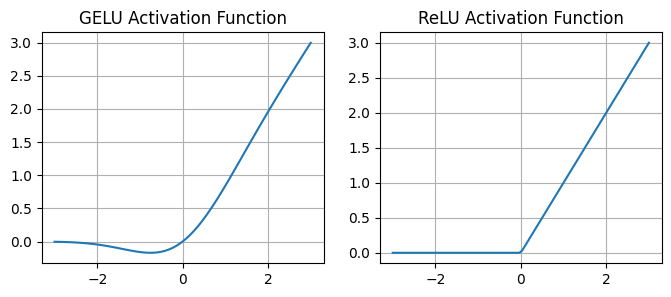

In [9]:
import matplotlib.pyplot as plt

gelu, relu = gpt.GELU(), torch.nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize= (8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x.numpy(), y.numpy())
    plt.title(f"{label} Activation Function")
    plt.grid(True)


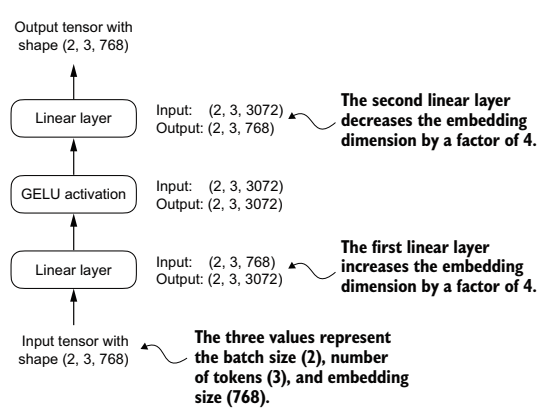

In [11]:
class FeedForward(torch.nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),
            gpt.GELU(),
            torch.nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim'])
        )
        
    def forward(self, x):
        return self.layers(x)
    
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.randn(2, 3, 768)
out = ffn(x)
print(out.shape)    ### [2, 3, 768]

torch.Size([2, 3, 768])


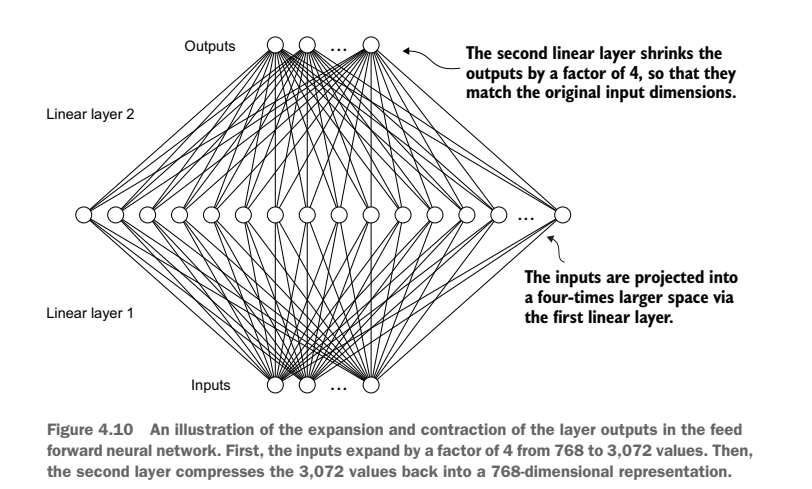

#### **Adding the Shortcut Connections**
These are also known as **Skip Connections** or **Residual Connections**. The shortcut connections helps with maintaining the relatively large gradients values even in early layers. 
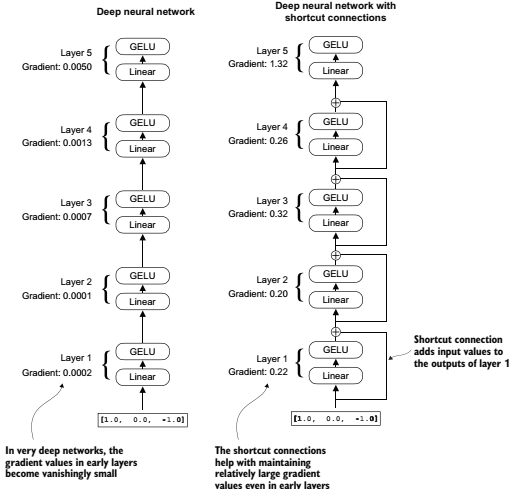

In [12]:
import torch.nn as nn

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                          gpt.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                          gpt.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                          gpt.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                          gpt.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                          gpt.GELU())
            ])
        
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
                
            else:
                x = layer_output
                
        return x

In [13]:
layers_size = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1.0, 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layers_size, use_shortcut=False)


In [14]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.0]])
    loss = nn.MSELoss()(output, target)
    loss.backward()
    
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [15]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173590746708214
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152042235247791
layers.3.0.weight has gradient mean of 0.0013988739810883999
layers.4.0.weight has gradient mean of 0.00504964729771018


In [16]:
#### with skip connections 
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layers_size, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694102346897125
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472
